In [211]:
import numpy as np
import scipy as sp
import scipy.stats as stats

import sympy as smp

In [212]:
import qiskit
from qiskit.primitives import StatevectorSampler
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import Statevector, Pauli
from qiskit.circuit.library import StatePreparation, UnitaryGate
from qiskit.visualization import plot_histogram


root2 = np.sqrt(2)

Simple rank 2 tensor determinant (2x2 matrix)

$
\begin{bmatrix}
    a & b \\\\
    c & d 
\end{bmatrix}
$

$|det M|^2$

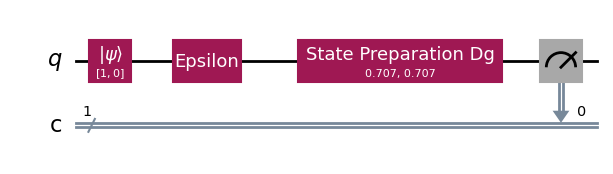

In [213]:
ψ = Statevector([1, 0])
φ = Statevector([1/root2, 1/root2])

V_dag = StatePreparation(φ).inverse()

antisym = UnitaryGate([
    [0, 1],
    [-1, 0]
])
antisym.name = "εpsilon"

circ = QuantumCircuit(1, 1)

circ.initialize(ψ)
circ.compose(antisym, inplace=True)
circ.compose(V_dag, inplace=True)

circ.measure(0, 0)
circ.draw('mpl')

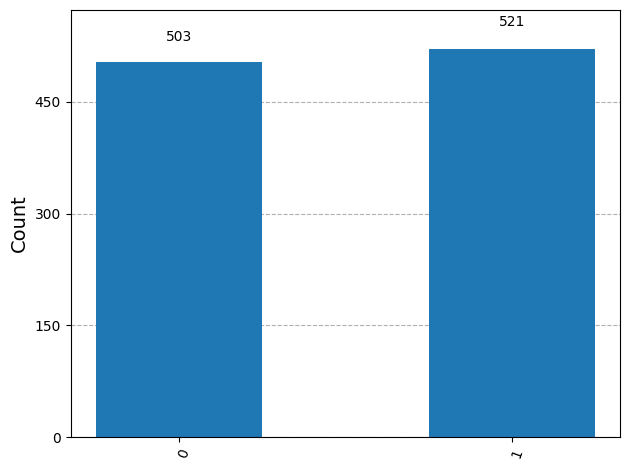

In [214]:
sampler = StatevectorSampler()
job = sampler.run([circ], shots=1024)

res = job.result()[0]
counts = res.data.c.get_counts()
plot_histogram(counts)

$P(0) = |det M|^2$

- When P(0) > P(1), the determinant is non-zero

Hadamard Primitive

In [ ]:
ψ = Statevector([1, 0])
φ = Statevector([1/root2, 1/root2])

rand_u = stats.unitary_group.rvs(2)

rand_u

array([[-0.20083833+0.41128164j,  0.64724578+0.60957713j],
       [-0.59731718+0.65857693j, -0.23255174-0.3942186j ]])

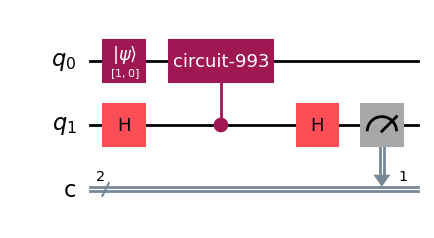

In [216]:


V_dag = StatePreparation(φ).inverse()

antisym = UnitaryGate([
    [0, 1],
    [-1, 0]
])
antisym.name = "εpsilon"

sub = QuantumCircuit(1)
sub.compose(antisym, inplace=True)
sub.compose(V_dag, inplace=True)

detGate = sub.to_gate()
CdetGate = detGate.control(1)

qc = QuantumCircuit(2, 2)
qc.initialize(ψ, 0)
qc.h(1)
qc.compose(CdetGate, qubits=[1, 0], inplace=True)
qc.h(1)

qc.measure(1, 1)

qc.draw('mpl')

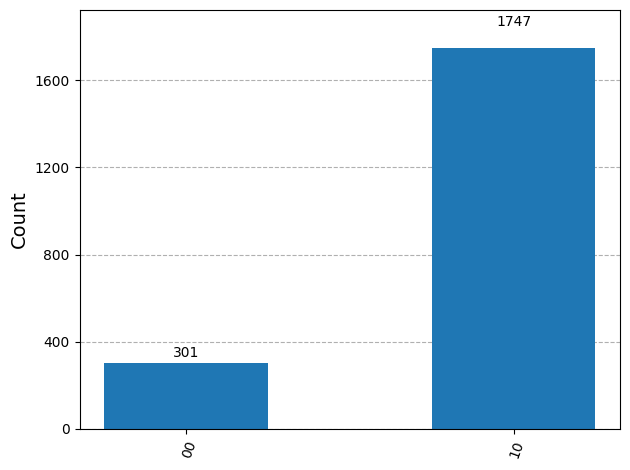

In [217]:
sampler = StatevectorSampler()
job = sampler.run([qc], shots=2048)

res = job.result()[0]
counts = res.data.c.get_counts()
plot_histogram(counts)

In [218]:
counts

{'10': 1747, '00': 301}

In [219]:
(counts['10'] / 2048) * 100

85.302734375